In [47]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [48]:
import pandas as pd

movies_df = pd.read_csv("movies.csv", encoding='utf-8')
ratings_df = pd.read_csv("ratings.csv", encoding='utf-8', parse_dates=["rated_at"])
users_df = pd.read_csv("users.csv", encoding='utf-8')

print(movies_df.shape, ratings_df.shape, users_df.shape)

(4, 5) (20, 6) (4, 5)


In [49]:
ratings_df[ratings_df['rating'].isnull()]

,rating_id,user_id,movie_id,rated_at,rating,review_status
16,RT017,U003,M002,2026-01-04 20:00:00,NaN,OK


In [50]:
ratings_df['review_status'].value_counts()

review_status
OK         16
SUSPECT     3
BAD         1
Name: count, dtype: int64

In [51]:
ratings_df['user_id'].value_counts()

user_id
U002    6
U001    5
U003    5
U004    4
Name: count, dtype: int64

In [52]:
ratings_df['movie_id'].value_counts()

movie_id
M003    9
M001    5
M002    5
M004    1
Name: count, dtype: int64

In [53]:
movies_df[movies_df['movie_id']=='M003']

,movie_id,title,genre,release_year,is_available
2,M003,Laugh Out Loud,Comedy,2021,1


Q1. B

Q2. B

Q5. B

Q6. B

Q9. C

Q10. B

Q11. C

In [54]:
# Q7.
def is_bad(rs, r):
    if rs == "BAD":
        return True
    elif r == None:
        return True
    else:
        return False
    
is_bad("OK", None)

True

In [77]:
# Q8.
def sum_ignore_none(values):
    sum = 0
    for i in range(0, len(values)):
        if values[i] == None:
            continue
        else:
            sum+=values[i]
    return sum

sum_ignore_none([1, None, 3])

4

In [ ]:
# 튜터님 답안
def sum_ignore_none(values):
    total = 0 
    for value in values:
        if value is None:
            continue
        else:
            total+=value
    return total

sum_ignore_none([1, None, 3])

4

In [ ]:
# Q12.
import pandas as pd

movies_df = pd.read_csv("movies.csv", encoding='utf-8')
ratings_df = pd.read_csv("ratings.csv", encoding='utf-8', parse_dates=["rated_at"])
users_df = pd.read_csv("users.csv", encoding='utf-8')

print(users_df.shape)
print(movies_df.shape)
print(ratings_df.shape)
print(ratings_df.head(2))

(4, 5)
(4, 5)
(20, 6)
  rating_id user_id movie_id            rated_at  rating review_status
0     RT001    U001     M003 2026-01-01 20:00:00     4.0            OK
1     RT002    U002     M003 2026-01-01 20:00:00     5.0            OK


In [ ]:
# Q13.
import pandas as pd

movies_df = pd.read_csv("movies.csv", encoding='utf-8')
ratings_df = pd.read_csv("ratings.csv", encoding='utf-8', parse_dates=["rated_at"])
users_df = pd.read_csv("users.csv", encoding='utf-8')

dup_cnt = ratings_df.duplicated(subset=['user_id','movie_id','rated_at']).sum()
print(f"dup_cnt: {dup_cnt}")

ratings_df = ratings_df.drop_duplicates(subset=['user_id','movie_id','rated_at'], keep="first")
ratings_df['rating_num'] = pd.to_numeric(ratings_df['rating'], errors="coerce")
df_full = ratings_df.merge(movies_df, on="movie_id", how="left")
df_full = df_full.merge(users_df, on="user_id", how="left")

df_clean = df_full[df_full["is_available"]==1 & df_full["review_status"].isin(["OK","SUSPECT"]) & ~df_full['rating_num'].isnull()]
print(f"rows: {len(df_clean)}")
# df_clean 만들 때 세가지 조건이 들어가야하는데 & 연산자로 묶을 때 괄호로 계산 순서를 먼저 지정해주었어야함

dup_cnt: 1
rows: 16


In [67]:
# Q14.
import pandas as pd

movies_df = pd.read_csv("movies.csv", encoding='utf-8')
ratings_df = pd.read_csv("ratings.csv", encoding='utf-8', parse_dates=["rated_at"])
users_df = pd.read_csv("users.csv", encoding='utf-8')

dup_cnt = ratings_df.duplicated(subset=['user_id','movie_id','rated_at']).sum()

ratings_df = ratings_df.drop_duplicates(subset=['user_id','movie_id','rated_at'], keep="first")
ratings_df['rating_num'] = pd.to_numeric(ratings_df['rating'], errors="coerce")
df_full = ratings_df.merge(movies_df, on="movie_id", how="left")
df_full = df_full.merge(users_df, on="user_id", how="left")

df_clean = df_full[df_full["is_available"]==1 & df_full["review_status"].isin(["OK","SUSPECT"]) & ~df_full['rating_num'].isnull()]
df = df_clean[['city','genre','rating']]

rating_cnt = df.groupby(['city','genre']).count().reset_index()
avg_rating = df.groupby(['city','genre'])['rating'].mean().round(1).reset_index()

df = df.merge(rating_cnt, on=['city','genre'], how='left')
df = df.merge(avg_rating, on=['city','genre'], how='left')

df.sort_values(by=['city','genre'], ascending=[True,False])

,city,genre,rating_x,rating_y,rating
12,BUSAN,Sci-Fi,2.0,1,2.0
15,BUSAN,Romance,3.0,1,3.0
1,BUSAN,Comedy,5.0,3,4.3
5,BUSAN,Comedy,4.0,3,4.3
8,BUSAN,Comedy,4.0,3,4.3
2,INCHEON,Sci-Fi,4.0,2,4.5
14,INCHEON,Sci-Fi,5.0,2,4.5
9,INCHEON,Comedy,5.0,1,5.0
4,SEOUL,Sci-Fi,5.0,2,4.5
11,SEOUL,Sci-Fi,4.0,2,4.5


Q15. B
Q16. A

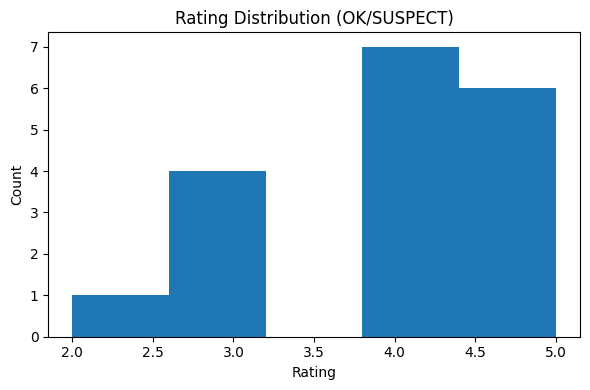

In [70]:
# Q17.
import pandas as pd
import matplotlib.pyplot as plt

ratings_df = pd.read_csv("ratings.csv", encoding='utf-8', parse_dates=["rated_at"])

ratings_df = ratings_df[ratings_df['review_status'].isin(["OK","SUSPECT"]) & ~ratings_df['rating'].isnull()]

plt.figure(figsize=(6,4))
plt.hist(ratings_df['rating'], bins=5)
plt.title("Rating Distribution (OK/SUSPECT)")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

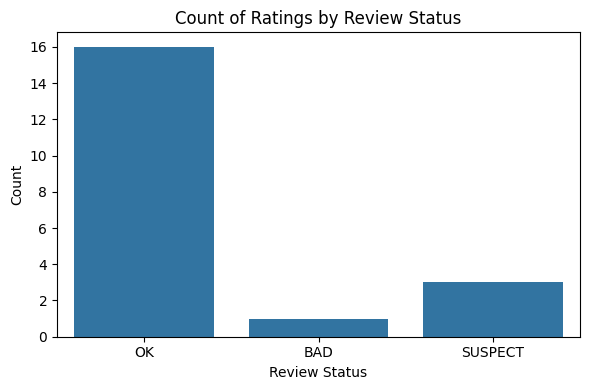

In [72]:
# Q18.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ratings_df = pd.read_csv("ratings.csv", encoding='utf-8', parse_dates=["rated_at"])

plt.figure(figsize=(6,4))
sns.countplot(ratings_df, x='review_status')
plt.title("Count of Ratings by Review Status")
plt.xlabel("Review Status")
plt.ylabel("Count")
plt.tight_layout() 